In [1]:
# Phase 17 – Robustness Analysis | Cell 1: Setup

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import pickle
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase17"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

P4 = PROJECT / "outputs" / "phase4" / "data"
P8 = PROJECT / "outputs" / "phase8" / "data"

print("=" * 60)
print("Phase 17 – Robustness Analysis | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")
print("Scenarios: Random Failure | Targeted Attack | Cascading Failure | Compound Crisis")

with open(P4 / "temporal_trade_networks.pkl", "rb") as f:
    networks_by_year = pickle.load(f)
years = sorted([int(y) for y in networks_by_year.keys()])
G0 = networks_by_year[years[-1]]
print(f"Focus graph year={years[-1]} | type={type(G0)}")

def as_U(G):
    if isinstance(G, nx.DiGraph) or (hasattr(G, "is_directed") and G.is_directed()):
        U = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
            if U.has_edge(u, v):
                U[u][v]["weight"] += w
            else:
                U.add_edge(u, v, weight=w)
        U.add_nodes_from(G.nodes())
        return U
    U = G.copy()
    for u, v, d in U.edges(data=True):
        d["weight"] = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
    return U

G = as_U(G0)
BASE_W = float(sum(d["weight"] for *_, d in G.edges(data=True)))
print(f"Nodes={G.number_of_nodes()} Edges={G.number_of_edges()} BaseWeight={BASE_W:.3e}")
print("Cell 1 completed successfully.")

Phase 17 – Robustness Analysis | Cell 1
Timestamp : 2026-10-05 11:24:48
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase17
Scenarios: Random Failure | Targeted Attack | Cascading Failure | Compound Crisis
Focus graph year=2020 | type=<class 'networkx.classes.digraph.DiGraph'>
Nodes=18 Edges=153 BaseWeight=4.171e+09
Cell 1 completed successfully.


Phase 17 – Cell 2: Random / Targeted / Cascading / Compound
Raw rows: 90

=== Scenario summary ===
        scenario  mean_retained_weight  min_retained_weight  mean_weight_loss  max_weight_loss  mean_lcc  min_lcc
CascadingFailure              0.170696             0.000000          0.829304         1.000000  0.333333 0.000000
  CompoundCrisis              0.224313             0.096564          0.775687         0.903436  0.861111 0.777778
  TargetedAttack              0.260651             0.043566          0.739349         0.956434  0.753968 0.500000
   RandomFailure              0.766720             0.344065          0.233280         0.655935  1.000000 1.000000

--- Worst Cascading (top 5) ---
 intensity  threshold  retained_weight  lcc_fraction  nodes_removed_total
      0.05        0.7              0.0           0.0                 18.0
      0.10        0.5              0.0           0.0                 18.0
      0.10        0.7              0.0           0.0                 18.0
  

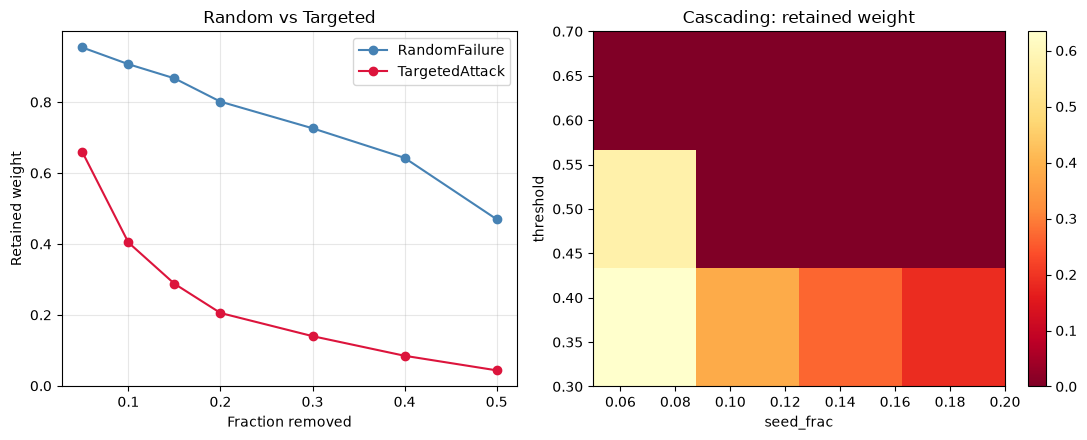

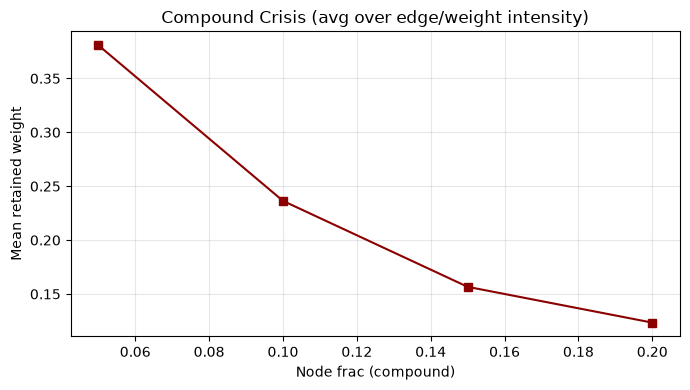


Cell 2 completed successfully.
PHASE 17 COMPLETED.


In [2]:
# Phase 17 – Cell 2: Four robustness scenarios

from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase17" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase17" / "figures"

print("=" * 60)
print("Phase 17 – Cell 2: Random / Targeted / Cascading / Compound")
print("=" * 60)

def metrics(H, base_w=BASE_W, base_n=None):
    if base_n is None:
        base_n = G.number_of_nodes()
    w = float(sum(d["weight"] for *_, d in H.edges(data=True))) if H.number_of_edges() else 0.0
    n = H.number_of_nodes()
    if n == 0:
        lcc = 0.0
    else:
        comps = list(nx.connected_components(H))
        lcc = max(len(c) for c in comps) / base_n if comps else 0.0
    try:
        dens = nx.density(H) if n > 1 else 0.0
    except Exception:
        dens = 0.0
    try:
        ge = nx.global_efficiency(H) if n > 1 else 0.0
    except Exception:
        ge = 0.0
    return {
        "retained_weight": w / (base_w + 1e-12),
        "weight_loss": 1.0 - w / (base_w + 1e-12),
        "lcc_fraction": lcc,
        "density": dens,
        "global_efficiency": ge,
        "n_nodes": n,
        "n_edges": H.number_of_edges(),
    }

def strength(H):
    return dict(H.degree(weight="weight"))

# ---------- 1) Random Failure: remove fraction of edges ----------
def random_failure(G, frac, seed=0):
    H = G.copy()
    edges = list(H.edges())
    rng = np.random.default_rng(seed)
    k = int(round(frac * len(edges)))
    if k > 0:
        idx = rng.choice(len(edges), size=min(k, len(edges)), replace=False)
        H.remove_edges_from([edges[i] for i in idx])
    return H

# ---------- 2) Targeted Attack: remove top strength nodes ----------
def targeted_attack(G, frac):
    H = G.copy()
    st = strength(H)
    order = [x for x, _ in sorted(st.items(), key=lambda kv: -kv[1])]
    k = int(round(frac * len(order)))
    if k > 0:
        H.remove_nodes_from(order[:k])
    return H

# ---------- 3) Cascading Failure ----------
def cascading_failure(G, seed_frac=0.1, threshold=0.5, max_iter=20):
    """
    Start by removing top seed_frac strength nodes.
    Then iteratively remove nodes whose remaining strength
    falls below threshold * original strength.
    """
    H = G.copy()
    st0 = strength(G)
    order = [x for x, _ in sorted(st0.items(), key=lambda kv: -kv[1])]
    k0 = max(1, int(round(seed_frac * len(order))))
    removed = set(order[:k0])
    H.remove_nodes_from(list(removed))
    for _ in range(max_iter):
        st = strength(H)
        to_drop = []
        for n, s in st.items():
            if s < threshold * st0.get(n, s):
                to_drop.append(n)
        if not to_drop:
            break
        H.remove_nodes_from(to_drop)
        removed.update(to_drop)
    return H, len(removed)

# ---------- 4) Compound Crisis ----------
def compound_crisis(G, edge_frac=0.2, node_frac=0.15, intensity=0.5, seed=0):
    """
    Combine: (a) targeted node removal, (b) random edge removal,
    (c) residual weight shock on remaining hub edges.
    """
    H = targeted_attack(G, node_frac)
    H = random_failure(H, edge_frac, seed=seed)
    st = strength(H)
    if st:
        order = [x for x, _ in sorted(st.items(), key=lambda kv: -kv[1])]
        hubs = set(order[:max(1, int(0.2 * len(order)))])
        for u, v, d in H.edges(data=True):
            if u in hubs or v in hubs:
                d["weight"] *= (1.0 - 0.7 * intensity)
            else:
                d["weight"] *= (1.0 - 0.3 * intensity)
    return H

fractions = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
rows = []

# Random Failure
for f in fractions:
    for seed in range(5):
        H = random_failure(G, f, seed=seed)
        m = metrics(H)
        m.update({"scenario": "RandomFailure", "intensity": f, "seed": seed})
        rows.append(m)

# Targeted Attack
for f in fractions:
    H = targeted_attack(G, f)
    m = metrics(H)
    m.update({"scenario": "TargetedAttack", "intensity": f, "seed": 0})
    rows.append(m)

# Cascading Failure (vary seed_frac and threshold)
for seed_frac in [0.05, 0.10, 0.15, 0.20]:
    for thr in [0.3, 0.5, 0.7]:
        H, nrem = cascading_failure(G, seed_frac=seed_frac, threshold=thr)
        m = metrics(H)
        m.update({
            "scenario": "CascadingFailure",
            "intensity": seed_frac,
            "threshold": thr,
            "nodes_removed_total": nrem,
            "seed": 0,
        })
        rows.append(m)

# Compound Crisis
for node_frac in [0.05, 0.10, 0.15, 0.20]:
    for edge_frac in [0.10, 0.20, 0.30]:
        for intensity in [0.25, 0.50, 0.75]:
            H = compound_crisis(G, edge_frac=edge_frac, node_frac=node_frac,
                                intensity=intensity, seed=0)
            m = metrics(H)
            m.update({
                "scenario": "CompoundCrisis",
                "intensity": node_frac,
                "edge_frac": edge_frac,
                "weight_intensity": intensity,
                "seed": 0,
            })
            rows.append(m)

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase17_all_scenarios_raw.csv", index=False)
print("Raw rows:", len(df))

# summaries
summary = (
    df.groupby(["scenario"], as_index=False)
      .agg(
          mean_retained_weight=("retained_weight", "mean"),
          min_retained_weight=("retained_weight", "min"),
          mean_weight_loss=("weight_loss", "mean"),
          max_weight_loss=("weight_loss", "max"),
          mean_lcc=("lcc_fraction", "mean"),
          min_lcc=("lcc_fraction", "min"),
      )
      .sort_values("mean_retained_weight")
)
summary.to_csv(OUT_TAB / "phase17_scenario_summary.csv", index=False)
print("\n=== Scenario summary ===")
print(summary.to_string(index=False))

# intensity curves for Random & Targeted
curve = (
    df[df.scenario.isin(["RandomFailure", "TargetedAttack"])]
      .groupby(["scenario", "intensity"], as_index=False)
      .agg(retained_weight=("retained_weight", "mean"),
           lcc_fraction=("lcc_fraction", "mean"),
           weight_loss=("weight_loss", "mean"))
)
curve.to_csv(OUT_TAB / "phase17_random_vs_targeted_curves.csv", index=False)

# worst compound / cascade
casc = df[df.scenario == "CascadingFailure"].sort_values("retained_weight")
comp = df[df.scenario == "CompoundCrisis"].sort_values("retained_weight")
print("\n--- Worst Cascading (top 5) ---")
print(casc.head(5)[["intensity", "threshold", "retained_weight", "lcc_fraction", "nodes_removed_total"]].to_string(index=False))
print("\n--- Worst Compound (top 5) ---")
print(comp.head(5)[["intensity", "edge_frac", "weight_intensity", "retained_weight", "lcc_fraction"]].to_string(index=False))

# plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for scen, c in zip(["RandomFailure", "TargetedAttack"], ["steelblue", "crimson"]):
    sub = curve[curve.scenario == scen]
    axes[0].plot(sub["intensity"], sub["retained_weight"], marker="o", color=c, label=scen)
axes[0].set_xlabel("Fraction removed")
axes[0].set_ylabel("Retained weight")
axes[0].set_title("Random vs Targeted")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# cascade heatmap-like: mean retained by seed_frac x threshold
piv = casc.pivot_table(index="threshold", columns="intensity", values="retained_weight", aggfunc="mean")
im = axes[1].imshow(piv.values, aspect="auto", origin="lower", cmap="YlOrRd_r",
                    extent=[piv.columns.min(), piv.columns.max(), piv.index.min(), piv.index.max()])
axes[1].set_xlabel("seed_frac")
axes[1].set_ylabel("threshold")
axes[1].set_title("Cascading: retained weight")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase17_random_targeted_cascade.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
comp_agg = (
    comp.groupby("intensity", as_index=False)["retained_weight"].mean()
        .sort_values("intensity")
)
ax.plot(comp_agg["intensity"], comp_agg["retained_weight"], marker="s", color="darkred")
ax.set_xlabel("Node frac (compound)")
ax.set_ylabel("Mean retained weight")
ax.set_title("Compound Crisis (avg over edge/weight intensity)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase17_compound.png", dpi=150)
plt.show()

print("\nCell 2 completed successfully.")
print("PHASE 17 COMPLETED.")